In [1]:
import pandas as pd
import json
import seaborn.objects as so
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
def read_jsonl_to_dataframe(jsonl_path):
    # Reads a .jsonl file and returns a pandas DataFrame.
    with open(jsonl_path, "r", encoding="utf-8") as f:
        records = [json.loads(line) for line in f]
    return pd.DataFrame(records)

# llama_neg = read_jsonl_to_dataframe("lls_as_a_judge_results_llama_neg.jsonl")
# llama_pos = read_jsonl_to_dataframe("lls_as_a_judge_results_llama_pos.jsonl")


In [4]:
llama_neg = [read_jsonl_to_dataframe(f"llm_as_a_judge_results/llama/neg/run_{i+1}.jsonl") for i in range(5)]
llama_pos = [read_jsonl_to_dataframe(f"llm_as_a_judge_results/llama/pos/run_{i+1}.jsonl") for i in range(5)]


In [7]:
def get_majority_labels(dataframes):
    combined = pd.concat(dataframes, ignore_index=True)
    majority_labels = (
        combined.groupby(['layer_index', 'prompt'])['label']
        .agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0])
        .reset_index()
    )
    return majority_labels

# Apply to both datasets
llama_neg_majority = get_majority_labels([llama_neg[i] for i in range(5)])
llama_pos_majority = get_majority_labels([llama_pos[i] for i in range(5)])

In [8]:
llama_neg_majority.head()

,layer_index,prompt,label
0,0,Am anxious,not coherent
1,0,Am excited,not coherent
2,0,Am sad,not coherent
3,0,Explain the meaning of life,not coherent
4,0,Feel happy,not coherent


In [9]:
sns.set_theme(style="whitegrid")

In [10]:
all_labels = pd.concat([llama_neg_majority['label'], llama_pos_majority['label']]).unique()
colorblind_palette = sns.color_palette("colorblind", n_colors=len(all_labels))
color_mapping = dict(zip(all_labels, colorblind_palette))

/scratch/ipykernel_3677048/1677997779.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper right', frameon=True, bbox_to_anchor=(0.98, 0.98))
/scratch/ipykernel_3677048/1677997779.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper right', frameon=True, bbox_to_anchor=(0.98, 0.98))


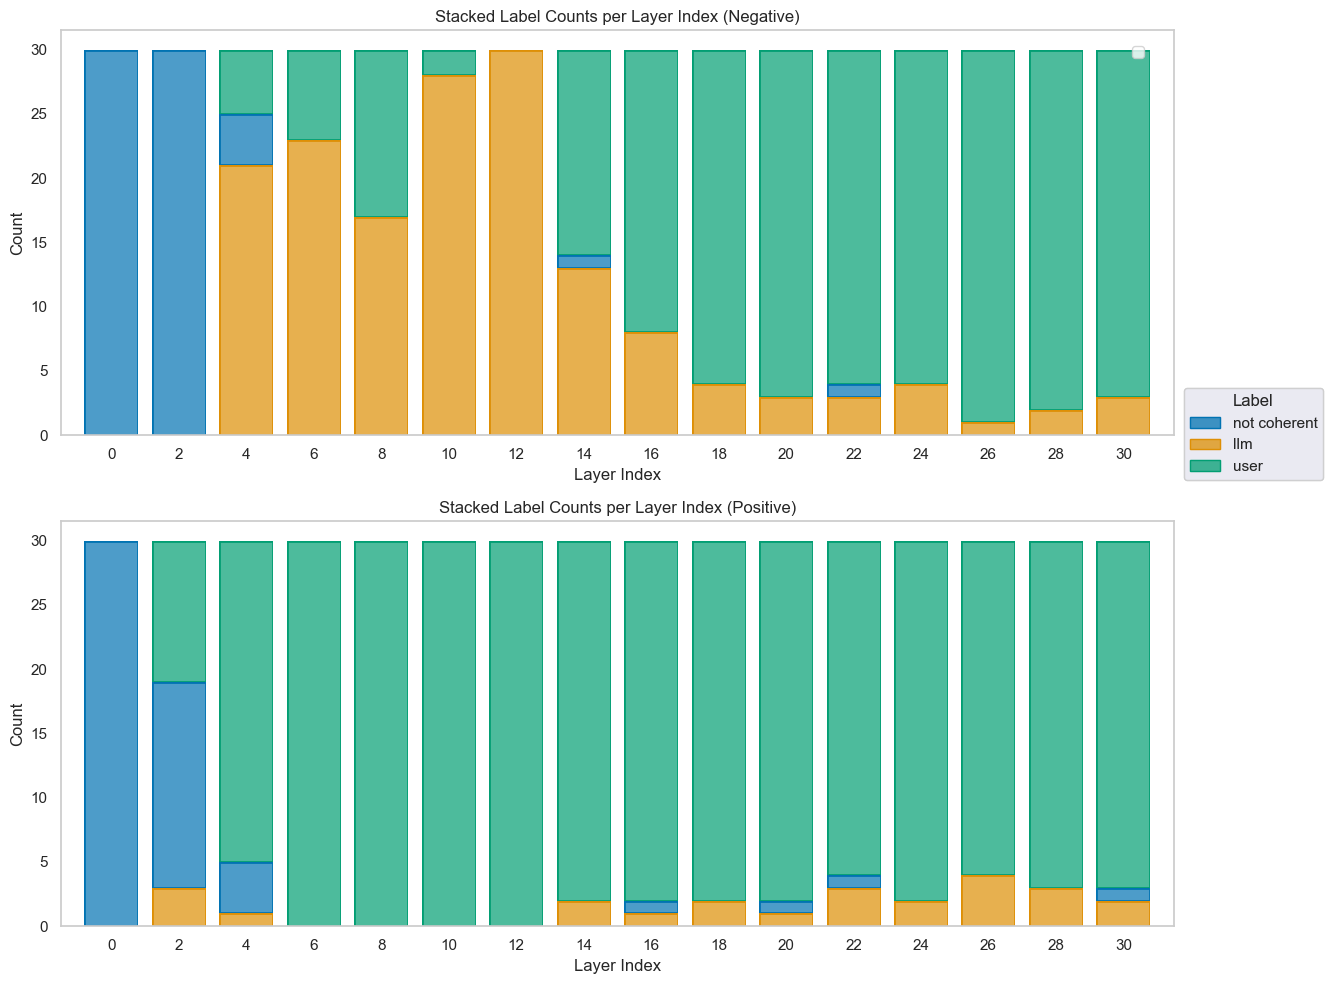

In [11]:
# Prepare negative data
llama_neg_majority['layer_index'] = llama_neg_majority['layer_index'].astype(int)
llama_neg_counts = llama_neg_majority.groupby(['layer_index', 'label']).size().reset_index(name='count')
llama_neg_counts = llama_neg_counts.sort_values('layer_index', ascending=True)
min_layer_neg = llama_neg_counts['layer_index'].min()
max_layer_neg = llama_neg_counts['layer_index'].max()

# Prepare positive data
llama_pos_majority['layer_index'] = llama_pos_majority['layer_index'].astype(int)
llama_pos_counts = llama_pos_majority.groupby(['layer_index', 'label']).size().reset_index(name='count')
llama_pos_counts = llama_pos_counts.sort_values('layer_index', ascending=True)
min_layer_pos = llama_pos_counts['layer_index'].min()
max_layer_pos = llama_pos_counts['layer_index'].max()

# Create figure with two subplots (2 rows, 1 column)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))


# Plot 1 - Negative (top)
p1 = (
    so.Plot(llama_neg_counts, x="layer_index", y="count", color="label")
    .add(so.Bar(), so.Stack())
    .scale(
        color=color_mapping,
        x=so.Continuous().tick(every=2)
    )
    .limit(x=(min_layer_neg - 1.5, max_layer_neg + 1.5))
    .label(
        title="Stacked Label Counts per Layer Index (Negative)",
        x="Layer Index",
        y="Count",
        color="Label"
    )
    .on(ax1)
    .plot()
)

# Plot 2 - Positive (bottom)
p2 = (
    so.Plot(llama_pos_counts, x="layer_index", y="count", color="label")
    .add(so.Bar(), so.Stack())
    .scale(
        color=color_mapping,
        x=so.Continuous().tick(every=2)
    )
    .limit(x=(min_layer_pos - 1.5, max_layer_pos + 1.5))
    .label(
        title="Stacked Label Counts per Layer Index (Positive)",
        x="Layer Index",
        y="Count",
        color="Label"
    )
    .on(ax2)
    .plot()
)

ax1.grid(False)
ax2.grid(False)

# Reposition legends for both plots
ax1.legend(loc='upper right', frameon=True, bbox_to_anchor=(0.98, 0.98))
ax2.legend(loc='upper right', frameon=True, bbox_to_anchor=(0.98, 0.98))
ax2.get_legend().remove()

plt.tight_layout()
# plt.show()
plt.savefig("stacked_label_counts_per_layer.pdf", dpi=300)